# FOMC Rate Decisions and Market Reaction: Event Study

## Mục tiêu

Xem thị trường có phản ứng với quyết định lãi suất của Fed (FOMC) không. Chia làm 3 câu hỏi:

1. **Q1:** SPY (thị trường chung) có biến động mạnh hơn vào quanh FOMC không?
2. **Q2:** AAPL, TLT, XLF chỉ đi theo thị trường, hay có mã nào phản ứng mạnh hơn bình thường?
3. **Q3 (extension):** VIX có tăng trước ngày họp và giảm sau đó không?



## 0. Import thư viện

In [1]:
!pip install arch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

%matplotlib inline

# Cố định seed để kết quả random (permutation, bootstrap) có thể tái tạo lại được.
RNG = np.random.default_rng(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 10.0 MB/s eta 0:00:00


## 1. Đọc dữ liệu và tính return

Hàm dùng chung cho 4 mã (SPY, AAPL, TLT, XLF), để xử lý giống nhau — kể cả bỏ dòng NaN đầu tiên (ngày đầu không có return vì chưa có ngày trước đó để so sánh).

In [2]:
raw_preview = pd.read_csv("spy_2013_2026.csv", skiprows=[1, 2]).rename(columns={"Price": "Date"})
raw_preview.head()

,Date,Close,High,Low,Open,Volume
0,2013-01-02,115.992897,116.064367,114.936682,115.238461,192059000
1,2013-01-03,115.730820,116.239072,115.421103,115.937305,144761800
2,2013-01-04,116.239075,116.429674,115.683175,115.921421,116817700
3,2013-01-07,115.921440,116.032620,115.492595,115.826147,110002500
4,2013-01-08,115.587875,115.873768,115.135207,115.714942,121265100


In [3]:
def load_price_series(path, name):
    """Đọc 1 file CSV giá (định dạng Yahoo Finance) và trả về DataFrame
    gồm 2 cột: Date và {name}_ret (lợi suất đơn giản mỗi ngày, dạng thập
    phân — ví dụ 0.01 nghĩa là +1%, không phải đã nhân 100)."""

    # skiprows=[1, 2]: bỏ 2 dòng metadata thừa mà Yahoo Finance hay chèn vào.
    raw = pd.read_csv(path, skiprows=[1, 2]).rename(columns={"Price": "Date"})

    # Chuyển cột Date từ string sang datetime.
    raw["Date"] = pd.to_datetime(raw["Date"])

    # Sắp xếp theo thời gian tăng dần.
    raw = raw.sort_values("Date").reset_index(drop=True)

    # Lợi suất đơn giản mỗi ngày: return_t = Close_t / Close_(t-1) - 1
    raw[f"{name}_ret"] = raw["Close"].pct_change()

    # Dòng đầu tiên luôn là NaN (không có ngày trước đó để so sánh).
    # Loại bỏ ngay tại đây để cả 4 mã được xử lý đồng nhất, thay vì chỉ dropna()
    # riêng cho SPY như bản trước.
    raw = raw.dropna(subset=[f"{name}_ret"]).reset_index(drop=True)

    return raw[["Date", f"{name}_ret"]]


# Đọc dữ liệu SPY, dùng làm đại diện cho thị trường chung.
spy = load_price_series("spy_2013_2026.csv", "spy").rename(columns={"spy_ret": "ret"})

# Đọc dữ liệu 3 mã còn lại.
aapl = load_price_series("aapl_2013_2026.csv", "aapl")
tlt = load_price_series("tlt_2013_2026.csv", "tlt")
xlf = load_price_series("xlf_2013_2026.csv", "xlf")

# Danh sách các ngày giao dịch của SPY, dùng để căn ngày sự kiện FOMC
# vào đúng ngày giao dịch gần nhất.
trading_dates = sorted(spy["Date"].tolist())
trading_dates_set = set(trading_dates)

print(f"SPY: {len(spy)} ngày giao dịch "
      f"({spy['Date'].min().date()} đến {spy['Date'].max().date()})")


SPY: 3430 ngày giao dịch (2013-01-03 đến 2026-08-24)


In [4]:
aapl.head()

,Date,aapl_ret
0,2013-01-03,-0.012622
1,2013-01-04,-0.027855
2,2013-01-07,-0.005882
3,2013-01-08,0.002691
4,2013-01-09,-0.015629


## 2. Kiểm tra chất lượng dữ liệu

Kiểm tra: có thiếu dữ liệu không, có ngày trùng không, dữ liệu đã sắp xếp đúng thứ tự chưa.

In [5]:
assets = {"SPY": spy, "AAPL": aapl, "TLT": tlt, "XLF": xlf}

for name, df in assets.items():
    print(f"\n{name}")
    print("-" * 40)
    print(f"Số dòng dữ liệu: {len(df)}")
    print(f"Khoảng thời gian: {df['Date'].min().date()} đến {df['Date'].max().date()}")
    print("Số giá trị bị thiếu (NaN):")
    print(df.isna().sum())
    print(f"Số ngày bị trùng: {df['Date'].duplicated().sum()}")
    # Kiểm tra thứ tự thời gian: Date1​<Date2​<⋯<DateT​
    print(f"Ngày đã được sắp xếp tăng dần: {df['Date'].is_monotonic_increasing}")



SPY
----------------------------------------
Số dòng dữ liệu: 3430
Khoảng thời gian: 2013-01-03 đến 2026-08-24
Số giá trị bị thiếu (NaN):
Date    0
ret     0
dtype: int64
Số ngày bị trùng: 0
Ngày đã được sắp xếp tăng dần: True

AAPL
----------------------------------------
Số dòng dữ liệu: 3430
Khoảng thời gian: 2013-01-03 đến 2026-08-24
Số giá trị bị thiếu (NaN):
Date        0
aapl_ret    0
dtype: int64
Số ngày bị trùng: 0
Ngày đã được sắp xếp tăng dần: True

TLT
----------------------------------------
Số dòng dữ liệu: 3430
Khoảng thời gian: 2013-01-03 đến 2026-08-24
Số giá trị bị thiếu (NaN):
Date       0
tlt_ret    0
dtype: int64
Số ngày bị trùng: 0
Ngày đã được sắp xếp tăng dần: True

XLF
----------------------------------------
Số dòng dữ liệu: 3430
Khoảng thời gian: 2013-01-03 đến 2026-08-24
Số giá trị bị thiếu (NaN):
Date       0
xlf_ret    0
dtype: int64
Số ngày bị trùng: 0
Ngày đã được sắp xếp tăng dần: True


In [6]:
# Kiểm tra xem 3 mã còn lại có cùng bộ ngày giao dịch với SPY không.
# Nếu lệch nhiều, các bước merge phía sau có thể làm mất dữ liệu.
spy_dates = set(spy["Date"])

for name, df in {"AAPL": aapl, "TLT": tlt, "XLF": xlf}.items():
    asset_dates = set(df["Date"])
    missing_from_asset = spy_dates - asset_dates
    extra_in_asset = asset_dates - spy_dates

    print(f"\n{name}")
    print(f"Ngày có ở SPY nhưng thiếu ở {name}: {len(missing_from_asset)}")
    print(f"Ngày có ở {name} nhưng không có ở SPY: {len(extra_in_asset)}")



AAPL
Ngày có ở SPY nhưng thiếu ở AAPL: 0
Ngày có ở AAPL nhưng không có ở SPY: 0

TLT
Ngày có ở SPY nhưng thiếu ở TLT: 0
Ngày có ở TLT nhưng không có ở SPY: 0

XLF
Ngày có ở SPY nhưng thiếu ở XLF: 0
Ngày có ở XLF nhưng không có ở SPY: 0


## 3. Gán ngày công bố FOMC vào ngày giao dịch

Mỗi thông báo có ngày công bố và giờ công bố (trong giờ hay sau giờ). Cần tìm đúng ngày mà thị trường có thể phản ứng:

- Công bố **sau giờ**: ngày phản ứng là ngày giao dịch kế tiếp.
- Công bố **trong giờ**: ngày phản ứng là chính ngày đó (hoặc ngày giao dịch gần nhất sau đó).

In [7]:
fomc_events = pd.read_csv("fomc_events.csv")
fomc_events["announcement_date"] = pd.to_datetime(fomc_events["announcement_date"])

# Chỉ giữ các sự kiện nằm trong khoảng thời gian mà mình có dữ liệu giá SPY.
fomc_events = fomc_events[
    (fomc_events["announcement_date"] >= spy["Date"].min()) &
    (fomc_events["announcement_date"] <= spy["Date"].max())
].reset_index(drop=True)


def map_to_event_day(ann_date, timing, trading_dates_sorted):
    """Tìm ngày giao dịch mà thị trường phản ứng với thông báo FOMC."""
    if timing == "after_hours":
        candidates = [d for d in trading_dates_sorted if d > ann_date]
    else:
        candidates = [d for d in trading_dates_sorted if d >= ann_date]
    return candidates[0] if candidates else None


fomc_events["event_trading_day"] = fomc_events.apply(
    lambda r: map_to_event_day(r["announcement_date"], r["timing"], trading_dates),
    axis=1,
)

# Cửa sổ sự kiện là 3 ngày: [-1, 0, +1] quanh ngày phản ứng.
WINDOW = 1
event_windows = {}

for _, row in fomc_events.iterrows():
    ed = row["event_trading_day"]
    if ed not in trading_dates_set:
        continue
    idx = trading_dates.index(ed)
    lo, hi = idx - WINDOW, idx + WINDOW
    if lo >= 0 and hi < len(trading_dates):
        event_windows[ed] = list(range(lo, hi + 1))

print(f"Số sự kiện trong mẫu: {len(fomc_events)} | Số event window đã tạo: {len(event_windows)}")
fomc_events[["announcement_date", "direction", "scheduled", "event_trading_day"]]


Số sự kiện trong mẫu: 31 | Số event window đã tạo: 31


,announcement_date,direction,scheduled,event_trading_day
0,2015-12-16,hike,True,2015-12-16
1,2016-12-14,hike,True,2016-12-14
2,2017-03-15,hike,True,2017-03-15
3,2017-06-14,hike,True,2017-06-14
4,2017-12-13,hike,True,2017-12-13
5,2018-03-21,hike,True,2018-03-21
6,2018-06-13,hike,True,2018-06-13
7,2018-09-26,hike,True,2018-09-26
8,2018-12-19,hike,True,2018-12-19
9,2019-07-31,cut,True,2019-07-31


In [8]:
# Kiểm tra xem có 2 thông báo nào bị gán vào cùng 1 ngày giao dịch không.
duplicate_event_days = fomc_events[
    fomc_events["event_trading_day"].duplicated(keep=False)
].sort_values("event_trading_day")

print("Các ngày sự kiện bị trùng (nếu có):")
print(duplicate_event_days[["announcement_date", "timing", "event_trading_day"]])


Các ngày sự kiện bị trùng (nếu có):
Empty DataFrame
Columns: [announcement_date, timing, event_trading_day]
Index: []


In [9]:
# Kiểm tra các sự kiện không gán được vào ngày giao dịch nào (thiếu dữ liệu giá).
unmapped_events = fomc_events[fomc_events["event_trading_day"].isna()]

print(f"Số sự kiện không gán được: {len(unmapped_events)}")
if len(unmapped_events) > 0:
    display(unmapped_events)


Số sự kiện không gán được: 0


### 3b. Kiểm tra event window có bị trùng nhau không

Mỗi event window dài 3 ngày. Nếu 2 sự kiện FOMC quá gần nhau, một ngày có thể bị tính vào 2 window cùng lúc, làm sai kết quả Q1. Nên kiểm tra rõ, không nên chỉ giả định là không có.

In [10]:
all_window_rows = []
for ed, idx_list in event_windows.items():
    for idx in idx_list:
        all_window_rows.append({
            "event_date": ed,
            "index": idx,
            "date": trading_dates[idx],
        })

window_check = pd.DataFrame(all_window_rows)

# Nếu một "date" xuất hiện nhiều hơn 1 lần trong bảng này, nghĩa là ngày đó
# thuộc về nhiều hơn 1 event window -> có overlap.
overlapping_dates = window_check[
    window_check.duplicated("date", keep=False)
].sort_values("date")

print(f"Số ngày giao dịch bị chồng lấn giữa các event window: {len(overlapping_dates)}")

if len(overlapping_dates) > 0:
    display(overlapping_dates)
else:
    print("Không có overlap - mỗi ngày giao dịch chỉ thuộc về đúng 1 event window.")


Số ngày giao dịch bị chồng lấn giữa các event window: 0
Không có overlap - mỗi ngày giao dịch chỉ thuộc về đúng 1 event window.


## 4. Q1 - SPY có biến động cao hơn quanh các sự kiện FOMC không?



In [11]:
# abs_ret = trị tuyệt đối của return, dùng làm thước đo volatility chính
# cho Q1: nhìn thẳng vào biến động thực tế xảy ra mỗi ngày.
spy["abs_ret"] = spy["ret"].abs()

print(spy[["Date", "ret", "abs_ret"]].head())


        Date       ret   abs_ret
0 2013-01-03 -0.002259  0.002259
1 2013-01-04  0.004392  0.004392
2 2013-01-07 -0.002733  0.002733
3 2013-01-08 -0.002878  0.002878
4 2013-01-09  0.002542  0.002542


**Cách làm:** mỗi sự kiện lấy 1 cửa sổ 3 ngày `[-1, 0, +1]`, tính trung bình |return| mỗi ngày. So sánh số này giữa nhóm "có sự kiện" và nhóm "không có sự kiện". Dùng 4 phép kiểm định khác nhau (Welch, Mann-Whitney, permutation, bootstrap) để kết quả không phụ thuộc vào 1 phương pháp duy nhất.

In [12]:
# --- Tính chỉ số cho từng event window ---
event_level_rows = []
for ed, idx_list in event_windows.items():
    w = spy.iloc[idx_list]
    event_level_rows.append({
        "event_date": ed,
        "avg_ret": w["ret"].mean(),
        "avg_abs_ret": w["abs_ret"].mean(),
    })

event_level_df = (
    pd.DataFrame(event_level_rows)
    .merge(
        fomc_events[["event_trading_day", "direction", "scheduled"]],
        left_on="event_date", right_on="event_trading_day", how="left",
    )
    .drop(columns="event_trading_day")
    .sort_values("event_date")
    .reset_index(drop=True)
)

# --- Xây dựng các non-event window (nhóm so sánh) ---
# Loại bỏ luôn cả vùng đệm (buffer) 2 ngày quanh mỗi event window, để tránh
# lấy nhầm những ngày "gần sự kiện" làm mẫu "bình thường".
BUFFER = 2
excluded_idx = set()
for ed in event_windows:
    idx = trading_dates.index(ed)
    for offset in range(-WINDOW - BUFFER, WINDOW + BUFFER + 1):
        i = idx + offset
        if 0 <= i < len(trading_dates):
            excluded_idx.add(i)

eligible_idx = sorted(i for i in range(len(spy)) if i not in excluded_idx)

# Gom các ngày "hợp lệ" liên tiếp thành từng cụm 3 ngày.
non_event_stats = []
i = 0
while i + 2 < len(eligible_idx):
    if eligible_idx[i + 2] - eligible_idx[i] == 2:
        r = spy.iloc[eligible_idx[i]: eligible_idx[i] + 3]
        non_event_stats.append({
            "avg_ret": r["ret"].mean(),
            "avg_abs_ret": r["abs_ret"].mean(),
        })
        i += 3
    else:
        i += 1

non_event_df = pd.DataFrame(non_event_stats)

print(f"Số event window: {len(event_level_df)} | Số non-event window: {len(non_event_df)}")


Số event window: 31 | Số non-event window: 1061


### 4b. Sample-size sensitivity check

Nhóm event (31 sự kiện) nhỏ hơn nhiều so với nhóm non-event (hơn 1000 window). Để kiểm tra kết luận không phải do chênh lệch cỡ mẫu, ta lặp lại nhiều lần: mỗi lần chọn ngẫu nhiên đúng bằng số event non-event window (theo `avg_abs_ret`) rồi so với nhóm event.

**Lưu ý:** đây không phải bootstrap CI thật sự, vì chỉ phía non-event được chọn lại ngẫu nhiên, còn phía event giữ nguyên. Kết quả chỉ mang tính tham khảo.

In [13]:
event_x = event_level_df["avg_abs_ret"].values
non_event_y = non_event_df["avg_abs_ret"].values

n_event = len(event_x)
n_iter = 10_000

matched_diffs = np.empty(n_iter)

for i in range(n_iter):
    sampled_non_event = RNG.choice(non_event_y, size=n_event, replace=False)
    matched_diffs[i] = event_x.mean() - sampled_non_event.mean()

low, high = np.percentile(matched_diffs, [2.5, 97.5])

print(f"Subsample non-event xuống n={n_event}, lặp lại {n_iter} lần:")
print(f"  Chênh lệch trung bình = {matched_diffs.mean():+.5f}")
print(f"  Khoảng phần trăm [2.5, 97.5] = [{low:.5f}, {high:.5f}]")
print()
print("Đây KHÔNG phải bootstrap CI đúng nghĩa (chỉ non-event được resample,")
print("event giữ cố định). Chỉ dùng làm chỉ báo, không phải kiểm định chính thức.")


Subsample non-event xuống n=31, lặp lại 10000 lần:
  Chênh lệch trung bình = +0.00547
  Khoảng phần trăm [2.5, 97.5] = [0.00355, 0.00700]

Đây KHÔNG phải bootstrap CI đúng nghĩa (chỉ non-event được resample,
event giữ cố định). Chỉ dùng làm chỉ báo, không phải kiểm định chính thức.


### 4c. Chạy các phép kiểm định cho Q1

Hàm `run_tests` gộp 4 phép kiểm định: Welch t-test, Mann-Whitney U, permutation test, bootstrap CI.

In [14]:
def run_tests(x, y, label, n_iter=10_000, rng=RNG):
    t_stat, p_welch = stats.ttest_ind(x, y, equal_var=False)
    u_stat, p_mw = mannwhitneyu(x, y, alternative="two-sided")

    observed = x.mean() - y.mean()
    combined = np.concatenate([x, y])
    n_x = len(x)

    perm_diffs = np.empty(n_iter)
    for k in range(n_iter):
        permuted = rng.permutation(combined)
        perm_diffs[k] = permuted[:n_x].mean() - permuted[n_x:].mean()
    p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed))

    boot_diffs = np.array([
        rng.choice(x, len(x), replace=True).mean()
        - rng.choice(y, len(y), replace=True).mean()
        for _ in range(n_iter)
    ])
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    print(f"--- {label} ---")
    print(f"  Trung bình event={x.mean():.5f}  non-event={y.mean():.5f}  chênh lệch={observed:.5f}")
    print(f"  Welch t-test:  p={p_welch:.4f}   Mann-Whitney: p={p_mw:.4f}")
    print(f"  Permutation:   p={p_perm:.4f}   Bootstrap 95% CI: [{ci_low:.5f}, {ci_high:.5f}]")
    print()


print("=== Kiểm tra hướng của return ===")
run_tests(event_level_df["avg_ret"].values, non_event_df["avg_ret"].values, "Mean return")

print("=== Độ biến động (|return|) - có volatility tăng không? ===")
run_tests(event_level_df["avg_abs_ret"].values, non_event_df["avg_abs_ret"].values,
           f"Toàn bộ mẫu ({len(event_level_df)} sự kiện)")

emergency_mask = ~event_level_df["scheduled"]
n_emergency = int(emergency_mask.sum())
n_remaining = len(event_level_df) - n_emergency
run_tests(
    event_level_df.loc[~emergency_mask, "avg_abs_ret"].values,
    non_event_df["avg_abs_ret"].values,
    f"Loại {n_emergency} sự kiện cắt lãi suất khẩn cấp (Mar 2020) khỏi nhóm event (còn {n_remaining} sự kiện)",
)


=== Kiểm tra hướng của return ===
--- Mean return ---
  Trung bình event=0.00015  non-event=0.00080  chênh lệch=-0.00065
  Welch t-test:  p=0.6742   Mann-Whitney: p=0.2161
  Permutation:   p=0.4931   Bootstrap 95% CI: [-0.00360, 0.00236]

=== Độ biến động (|return|) - có volatility tăng không? ===
--- Toàn bộ mẫu (31 sự kiện) ---
  Trung bình event=0.01216  non-event=0.00667  chênh lệch=0.00548
  Welch t-test:  p=0.0550   Mann-Whitney: p=0.0205
  Permutation:   p=0.0002   Bootstrap 95% CI: [0.00110, 0.01148]

--- Loại 2 sự kiện cắt lãi suất khẩn cấp (Mar 2020) khỏi nhóm event (còn 29 sự kiện) ---
  Trung bình event=0.00882  non-event=0.00667  chênh lệch=0.00215
  Welch t-test:  p=0.0633   Mann-Whitney: p=0.0777
  Permutation:   p=0.0257   Bootstrap 95% CI: [0.00008, 0.00437]



### Trả lời Q1 (metric chính: |return|)

- **Hướng biến động:** không có bằng chứng thị trường đi lên hay xuống một cách hệ thống quanh ngày FOMC.

- **Độ biến động, toàn mẫu 31 sự kiện:** trung bình event = 1.22%, non-event = 0.67%, chênh lệch gần gấp đôi. **Bằng chứng không đồng nhất giữa các test:** Welch t-test (p=0.0550) không đạt ngưỡng 5% (dù rất sát), Mann-Whitney (p=0.0205) và permutation (p=0.0002) thì có, bootstrap 95% CI [0.0012, 0.0116] không chứa 0.

- **Sau khi loại 2 sự kiện cắt lãi suất khẩn cấp (Mar 2020), còn 29 sự kiện:** chênh lệch giảm gần một nửa (1.22% → 0.88%), Welch (p=0.063) và Mann-Whitney (p=0.078) đều không còn significant, chỉ permutation (p=0.022) và bootstrap CI [0.00004, 0.0043] (cận dưới sát 0) còn cho tín hiệu dương.

- **Kết luận:** SPY có xu hướng biến động mạnh hơn quanh FOMC, nhưng chưa đủ bằng chứng cho một hiệu ứng ổn định ở các cuộc họp thông thường.



/tmp/ipykernel_3834/2560095179.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_full, labels=["FOMC events\n(n=31)", "Non-event\n(n=1061)"])
/tmp/ipykernel_3834/2560095179.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_excl, labels=["FOMC events\n(n=29)", "Non-event\n(n=1061)"])


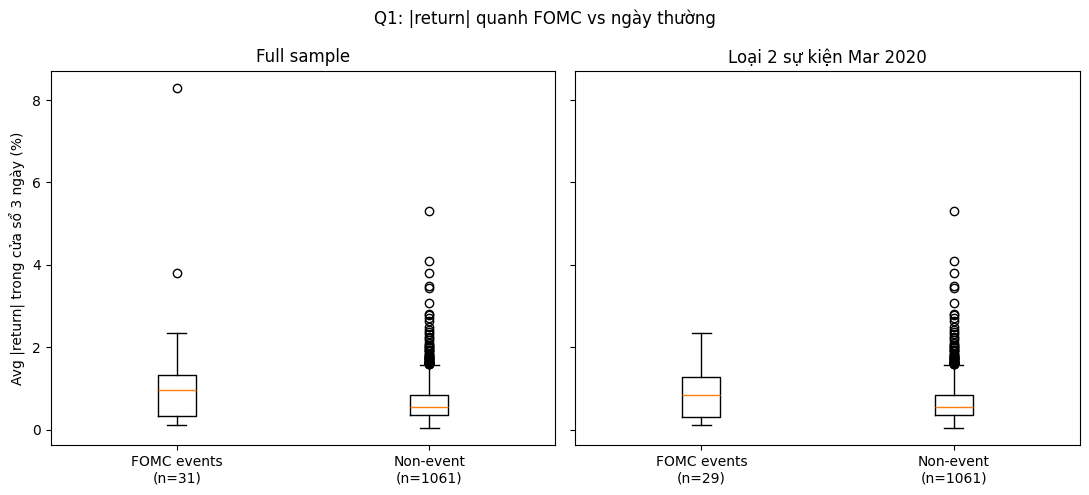

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# --- Full sample ---
data_full = [event_level_df["avg_abs_ret"] * 100, non_event_df["avg_abs_ret"] * 100]
axes[0].boxplot(data_full, labels=["FOMC events\n(n=31)", "Non-event\n(n=1061)"])
axes[0].set_title("Full sample")
axes[0].set_ylabel("Avg |return| trong cửa sổ 3 ngày (%)")

# --- Excluding 2 COVID emergency cuts ---
emergency_mask = ~event_level_df["scheduled"]
data_excl = [event_level_df.loc[~emergency_mask, "avg_abs_ret"] * 100, non_event_df["avg_abs_ret"] * 100]
axes[1].boxplot(data_excl, labels=["FOMC events\n(n=29)", "Non-event\n(n=1061)"])
axes[1].set_title("Loại 2 sự kiện Mar 2020")

fig.suptitle("Q1: |return| quanh FOMC vs ngày thường")
plt.tight_layout()
plt.show()

## 4d. Robustness check: đo volatility bằng model (walk-forward GARCH)

`|return|` là biến động *thực tế đã xảy ra* trong đúng 1 ngày, khá nhiễu vì chỉ nhìn 1 quan sát. Để kiểm tra kết luận Q1 có đứng vững với một cách đo volatility khác không, phần này lặp lại đúng phân tích trên nhưng dùng **GARCH(1,1) conditional volatility** — $\sigma_t = \sqrt{Var(R_t \mid \mathcal{F}_{t-1})}$, ước lượng theo kiểu walk-forward (refit định kỳ, chỉ dùng dữ liệu quá khứ tại mỗi thời điểm, không look-ahead).

In [15]:
def walk_forward_garch_conditional_vol(ret_pct, min_hist=750, refit_every=250):
    """Conditional volatility kiểu walk-forward, expanding window (không phải
    rolling fixed window) - không dùng dữ liệu tương lai để CHỌN tham số.
    Refit GARCH(1,1) định kỳ mỗi `refit_every` ngày, mỗi lần dùng toàn bộ
    lịch sử từ đầu đến thời điểm đó. Giữa 2 lần refit, tham số giữ cố định;
    sigma_t vẫn cập nhật mỗi ngày theo công thức GARCH với return thực tế.
    """
    n = len(ret_pct)
    cond_vol = np.full(n, np.nan)
    sigma2 = eps2 = omega = alpha = beta = mu = None

    for t in range(min_hist, n):
        if omega is None or (t - min_hist) % refit_every == 0:
            fit = arch_model(ret_pct[:t], vol="Garch", p=1, q=1, dist="t").fit(disp="off")
            omega = fit.params["omega"]
            alpha = fit.params["alpha[1]"]
            beta = fit.params["beta[1]"]
            mu = fit.params["mu"]
            sigma2 = fit.conditional_volatility[-1] ** 2
            eps2 = fit.resid[-1] ** 2

        sigma2 = omega + alpha * eps2 + beta * sigma2
        cond_vol[t] = np.sqrt(sigma2)

        eps_t = ret_pct[t] - mu
        eps2 = eps_t ** 2

    return cond_vol


raw_cond_vol = walk_forward_garch_conditional_vol(spy["ret"].values * 100, min_hist=750, refit_every=250)
spy["cond_vol"] = raw_cond_vol / 100

n_missing = spy["cond_vol"].isna().sum()
print(f"Số ngày không có cond_vol (chưa đủ lịch sử, ~{n_missing/252:.1f} năm đầu): {n_missing}")


# --- Lặp lại đúng phân tích Q1, nhưng dùng cond_vol thay vì abs_ret ---
event_level_garch_rows = []
for ed, idx_list in event_windows.items():
    w = spy.iloc[idx_list]
    event_level_garch_rows.append({
        "event_date": ed,
        "avg_cond_vol": w["cond_vol"].mean(),
    })

event_level_garch_df = (
    pd.DataFrame(event_level_garch_rows)
    .merge(fomc_events[["event_trading_day", "scheduled"]],
           left_on="event_date", right_on="event_trading_day", how="left")
    .drop(columns="event_trading_day")
)
n_before_g = len(event_level_garch_df)
event_level_garch_df = event_level_garch_df.dropna(subset=["avg_cond_vol"]).reset_index(drop=True)
print(f"Số sự kiện có đủ lịch sử để tính walk-forward GARCH: {len(event_level_garch_df)}/{n_before_g}")

non_event_garch_stats = []
i = 0
while i + 2 < len(eligible_idx):
    if eligible_idx[i + 2] - eligible_idx[i] == 2:
        r = spy.iloc[eligible_idx[i]: eligible_idx[i] + 3]
        non_event_garch_stats.append({"avg_cond_vol": r["cond_vol"].mean()})
        i += 3
    else:
        i += 1

non_event_garch_df = pd.DataFrame(non_event_garch_stats).dropna(subset=["avg_cond_vol"]).reset_index(drop=True)

print(f"\n=== Robustness check: GARCH conditional volatility ===")
run_tests(event_level_garch_df["avg_cond_vol"].values, non_event_garch_df["avg_cond_vol"].values,
           f"Toàn bộ mẫu ({len(event_level_garch_df)} sự kiện)")

emergency_mask_g = ~event_level_garch_df["scheduled"]
n_emergency_g = int(emergency_mask_g.sum())
run_tests(
    event_level_garch_df.loc[~emergency_mask_g, "avg_cond_vol"].values,
    non_event_garch_df["avg_cond_vol"].values,
    f"GARCH - loại {n_emergency_g} sự kiện Mar 2020 (còn {len(event_level_garch_df) - n_emergency_g} sự kiện)",
)


Số ngày không có cond_vol (chưa đủ lịch sử, ~3.0 năm đầu): 750
Số sự kiện có đủ lịch sử để tính walk-forward GARCH: 30/31

=== Robustness check: GARCH conditional volatility ===
--- Toàn bộ mẫu (30 sự kiện) ---
  Trung bình event=0.01220  non-event=0.00930  chênh lệch=0.00290
  Welch t-test:  p=0.1868   Mann-Whitney: p=0.4728
  Permutation:   p=0.0092   Bootstrap 95% CI: [-0.00053, 0.00767]

--- GARCH - loại 2 sự kiện Mar 2020 (còn 28 sự kiện) ---
  Trung bình event=0.00975  non-event=0.00930  chênh lệch=0.00045
  Welch t-test:  p=0.6376   Mann-Whitney: p=0.9135
  Permutation:   p=0.6361   Bootstrap 95% CI: [-0.00130, 0.00234]



### Insight

- GARCH cho kết quả **cùng chiều với `|return|`**, nhưng hiệu ứng yếu hơn.
- Bỏ 2 sự kiện **Mar 2020**, chênh lệch gần như mất (**+0.05pp**) và không còn significant.
- **Bài học:** kết quả full sample bị ảnh hưởng mạnh bởi COVID; hiệu ứng FOMC lên volatility **không thật sự ổn định**.

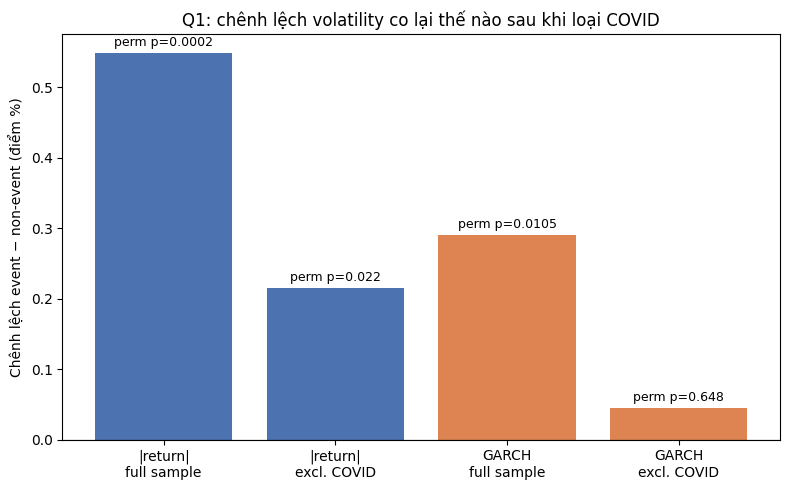

In [22]:
labels = ["|return|\nfull sample", "|return|\nexcl. COVID", "GARCH\nfull sample", "GARCH\nexcl. COVID"]
diffs = [
    event_level_df["avg_abs_ret"].mean() - non_event_df["avg_abs_ret"].mean(),
    event_level_df.loc[~emergency_mask, "avg_abs_ret"].mean() - non_event_df["avg_abs_ret"].mean(),
    event_level_garch_df["avg_cond_vol"].mean() - non_event_garch_df["avg_cond_vol"].mean(),
    event_level_garch_df.loc[~emergency_mask_g, "avg_cond_vol"].mean() - non_event_garch_df["avg_cond_vol"].mean(),
]
perm_p = [0.0002, 0.022, 0.0105, 0.648]  # lấy từ output run_tests() ở trên

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, [d * 100 for d in diffs], color=["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Chênh lệch event − non-event (điểm %)")
ax.set_title("Q1: chênh lệch volatility co lại thế nào sau khi loại COVID")

for bar, p in zip(bars, perm_p):
    ax.annotate(f"perm p={p}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                textcoords="offset points", xytext=(0, 5), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Q2a - Các mã có đi theo thị trường quanh sự kiện FOMC không?

Trước khi nói một mã phản ứng "bất thường", cần biết nó có đi cùng chiều với thị trường không **trong đúng bối cảnh đang xét (quanh sự kiện FOMC)** — đây chưa phải correlation toàn thời kỳ hay unconditional beta. AAPL, XLF là cổ phiếu nên có thể kỳ vọng đi theo thị trường; TLT (trái phiếu) phản ứng với kỳ vọng lãi suất, không nhất thiết theo tâm lý cổ phiếu.

**Cách làm:** với mỗi cửa sổ 3 ngày, tính return cộng dồn từng mã, so dấu (tăng/giảm) với SPY, và tính tương quan qua 31 sự kiện.

In [16]:
df_all = (
    spy[["Date", "ret"]]
    .rename(columns={"ret": "spy_ret"})
    .merge(aapl, on="Date")
    .merge(tlt, on="Date")
    .merge(xlf, on="Date")
    .dropna()
    .reset_index(drop=True)
)
dates_all = sorted(df_all["Date"].tolist())

comove_rows = []
for _, row in fomc_events.iterrows():
    ed = row["event_trading_day"]
    if ed not in dates_all:
        continue
    idx = dates_all.index(ed)
    if idx - 1 < 0 or idx + 1 >= len(dates_all):
        continue

    w = df_all.iloc[idx - 1: idx + 2]

    # Return cộng dồn đúng cách: (1+R1)(1+R2)(1+R3) - 1
    # (Cộng trực tiếp 3 return lại với nhau chỉ là một cách xấp xỉ.)
    comove_rows.append({
        "event_date": ed.date(),
        "direction": row["direction"],
        "SPY_%": ((1 + w["spy_ret"]).prod() - 1) * 100,
        "AAPL_%": ((1 + w["aapl_ret"]).prod() - 1) * 100,
        "TLT_%": ((1 + w["tlt_ret"]).prod() - 1) * 100,
        "XLF_%": ((1 + w["xlf_ret"]).prod() - 1) * 100,
    })

comove_df = pd.DataFrame(comove_rows)

print("=== % số sự kiện đi cùng hướng với SPY, và hệ số tương quan ===")
for asset in ["AAPL", "TLT", "XLF"]:
    same_dir = (np.sign(comove_df["SPY_%"]) == np.sign(comove_df[f"{asset}_%"])).mean() * 100
    corr = comove_df["SPY_%"].corr(comove_df[f"{asset}_%"])
    print(f"{asset}: {same_dir:.0f}% cùng hướng | r = {corr:.3f}")

comove_df.round(2)


=== % số sự kiện đi cùng hướng với SPY, và hệ số tương quan ===
AAPL: 74% cùng hướng | r = 0.826
TLT: 52% cùng hướng | r = -0.070
XLF: 84% cùng hướng | r = 0.901


,event_date,direction,SPY_%,AAPL_%,TLT_%,XLF_%
0,2015-12-16,hike,0.97,-3.11,0.32,2.51
1,2016-12-14,hike,0.25,2.22,-0.26,0.64
2,2017-03-15,hike,0.28,1.07,1.19,-0.28
3,2017-06-14,hike,0.17,-0.78,1.40,0.29
4,2017-12-13,hike,-0.24,-0.26,1.14,-0.89
5,2018-03-21,hike,-2.52,-3.68,0.69,-3.49
6,2018-06-13,hike,0.06,-0.22,0.80,-1.53
7,2018-09-26,hike,-0.11,1.88,0.67,-1.94
8,2018-12-19,hike,-3.21,-4.34,1.56,-2.50
9,2019-07-31,cut,-2.20,-0.60,3.06,-3.02


### Trả lời Q2a

- **AAPL và XLF thường đi cùng chiều với thị trường quanh FOMC** (74% và 84%, r = 0.83 và 0.90).
- Đây chỉ là **tương quan trong 31 cửa sổ 3 ngày quanh FOMC**, không phải correlation/beta toàn giai đoạn.
**->** hai tài sản phản ứng khá đồng bộ với thị trường quanh FOMC, nhưng chưa thể kết luận nguyên nhân hay mức độ nhạy cảm (beta).
- **TLT thì** ít đồng biến với SPY trong các cửa sổ FOMC, phù hợp với đặc điểm phản ứng khác nhau của TLT trước kỳ vọng lãi suất.

## 6. Q2b - Có mã nào phản ứng vượt mức "đi theo thị trường"?

Q2a gộp chung 2 điều: "vốn dĩ đi theo thị trường" và "phản ứng riêng với Fed". **Market Model** tách 2 phần này: ước lượng alpha/beta bình thường của mỗi mã so với SPY (từ cửa sổ trước sự kiện 21 ngày, để tránh lẫn hiệu ứng đón đầu). Sau đó tính **CAR (Cumulative Abnormal Return)** — phần biến động mà beta không giải thích được.

**Cửa sổ ước lượng cho mỗi sự kiện:**

```
|-- 120 ngày ước lượng beta --|-- 21 ngày cách --| [-1, 0, +1]
```

Mỗi sự kiện có cửa sổ ước lượng riêng, vì beta của AAPL hay XLF có thể đổi theo thời gian.

**CAR** ở đây là tổng abnormal return trong cửa sổ sự kiện:

```
CAR[-1,+1] = AR(-1) + AR(0) + AR(+1)
```

**Ghi chú:** cửa sổ `[-1, 0, +1]` được xác định theo `Date` thật của SPY, không theo vị trí trong bảng đã merge — tránh lệch ngày nếu asset thiếu dữ liệu một vài ngày.

In [17]:
def market_model_car(asset_ret_df, ret_col, label, est_len=120, gap=21, window=1):
    merged = pd.merge(
        asset_ret_df,
        spy[["Date", "ret"]].rename(columns={"ret": "mkt_ret"}),
        on="Date",
    ).dropna().reset_index(drop=True)
    dates_list = merged["Date"].tolist()

    def estimate(event_date):
        if event_date not in dates_list:
            return None

        idx = dates_list.index(event_date)
        est_start, est_end = idx - gap - est_len, idx - gap
        if est_start < 0:
            return None

        est_data = merged.iloc[est_start:est_end]

        # Kiểm tra rõ ràng cửa sổ ước lượng có đủ độ dài không, thay vì chỉ
        # dựa vào điều kiện est_start < 0 ở trên (viết explicit dễ đọc hơn).
        if len(est_data) < est_len:
            return None

        X = sm.add_constant(est_data["mkt_ret"])
        model = sm.OLS(est_data[ret_col], X).fit()
        alpha, beta = model.params["const"], model.params["mkt_ret"]

        # Xác định 3 ngày của event window [-1, 0, +1] TRỰC TIẾP theo
        # trading_dates của SPY (nguồn "sự thật" cho ngày sự kiện), rồi mới
        # lọc merged theo đúng các Date đó. Cách này tránh phụ thuộc vào vị
        # trí (positional index) trong merged, vốn có thể lệch khỏi ±1 ngày
        # giao dịch thực tế nếu asset thiếu một vài ngày so với SPY (dù ở
        # bước data-quality-check trước đó, AAPL/TLT/XLF gần như trùng khớp
        # hoàn toàn với ngày của SPY).
        spy_idx = trading_dates.index(event_date)
        lo = max(0, spy_idx - window)
        hi = min(len(trading_dates) - 1, spy_idx + window)
        wanted_dates = set(trading_dates[lo: hi + 1])

        event_rows = merged[merged["Date"].isin(wanted_dates)].sort_values("Date")
        if len(event_rows) == 0:
            return None

        expected = alpha + beta * event_rows["mkt_ret"]
        ar = event_rows[ret_col] - expected

        return {"car": ar.sum(), "beta": beta, "residuals": model.resid}

    results = {}
    for ed in fomc_events["event_trading_day"]:
        r = estimate(ed)
        if r is not None:
            results[ed] = r

    cars = np.array([r["car"] for r in results.values()])
    betas = np.array([r["beta"] for r in results.values()])

    t_stat, p_val = stats.ttest_1samp(cars, 0)
    w_stat, w_p = wilcoxon(cars)
    boot = np.array([RNG.choice(cars, len(cars), replace=True).mean() for _ in range(10_000)])
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    print(f"--- {label} ---")
    print(f"  Số sự kiện: {len(cars)}  Beta trung bình: {betas.mean():.2f}  CAR trung bình: {cars.mean():+.5f}")
    print(f"  t-test: p={p_val:.4f}  Wilcoxon: p={w_p:.4f}  Bootstrap 95% CI: [{ci_low:.5f}, {ci_high:.5f}]")
    print()
    return results


aapl_results = market_model_car(aapl, "aapl_ret", "AAPL")
tlt_results = market_model_car(tlt, "tlt_ret", "TLT")
xlf_results = market_model_car(xlf, "xlf_ret", "XLF")

--- AAPL ---
  Số sự kiện: 31  Beta trung bình: 1.24  CAR trung bình: +0.00072
  t-test: p=0.8450  Wilcoxon: p=0.7498  Bootstrap 95% CI: [-0.00646, 0.00772]

--- TLT ---
  Số sự kiện: 31  Beta trung bình: -0.14  CAR trung bình: +0.00442
  t-test: p=0.1166  Wilcoxon: p=0.1066  Bootstrap 95% CI: [-0.00099, 0.00963]

--- XLF ---
  Số sự kiện: 31  Beta trung bình: 0.98  CAR trung bình: -0.00248
  t-test: p=0.3070  Wilcoxon: p=0.1887  Bootstrap 95% CI: [-0.00696, 0.00220]



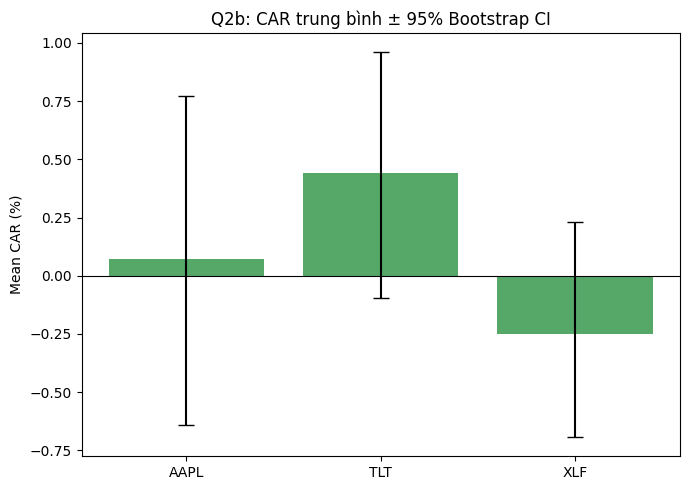

In [23]:
assets_car = {"AAPL": aapl_results, "TLT": tlt_results, "XLF": xlf_results}
means, ci_lows, ci_highs = [], [], []

for name, results in assets_car.items():
    cars = np.array([r["car"] for r in results.values()])
    boot = np.array([RNG.choice(cars, len(cars), replace=True).mean() for _ in range(10_000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    means.append(cars.mean() * 100)
    ci_lows.append((cars.mean() - lo) * 100)
    ci_highs.append((hi - cars.mean()) * 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(assets_car.keys(), means, yerr=[ci_lows, ci_highs], capsize=6, color="#55A868")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean CAR (%)")
ax.set_title("Q2b: CAR trung bình ± 95% Bootstrap CI")
plt.tight_layout()
plt.show()

## 7. Kiểm tra residual của Market Model

Kiểm tra residual theo từng cửa sổ riêng, không gộp chung tất cả lại. Nếu gộp chung, các năm bình thường sẽ bị trộn với năm biến động mạnh (như 2022), làm kết quả trông "không chuẩn" hơn thực tế.

In [18]:
def diagnostics_summary(results, label):
    rows = []
    for d, r in results.items():
        resid = r["residuals"].values
        if len(resid) < 20:
            continue

        _, jb_p, _, _ = jarque_bera(resid)
        try:
            _, arch_p, _, _ = het_arch(resid)
        except ValueError:
            arch_p = np.nan

        rows.append({"jb_p": jb_p, "arch_p": arch_p, "dw": durbin_watson(resid)})

    diag = pd.DataFrame(rows)
    print(f"{label}: {(diag['jb_p'] < 0.05).mean():.0%} cửa sổ không chuẩn (non-normal) | "
          f"{(diag['arch_p'] < 0.05).mean():.0%} cửa sổ có ARCH | DW trung bình={diag['dw'].mean():.2f}")


diagnostics_summary(aapl_results, "AAPL")
diagnostics_summary(tlt_results, "TLT")
diagnostics_summary(xlf_results, "XLF")


AAPL: 87% cửa sổ không chuẩn (non-normal) | 10% cửa sổ có ARCH | DW trung bình=1.84
TLT: 10% cửa sổ không chuẩn (non-normal) | 10% cửa sổ có ARCH | DW trung bình=2.01
XLF: 52% cửa sổ không chuẩn (non-normal) | 16% cửa sổ có ARCH | DW trung bình=1.97


In [19]:
# ============================================================
# Pooled ARCH-LM check (so sánh với per-window ở cell trên)
# ============================================================
# Gộp toàn bộ residual của tất cả event window lại thành 1 mảng duy nhất,
# rồi chạy ARCH-LM 1 lần trên mảng gộp đó. Nếu p-value pooled rất nhỏ
# (ví dụ < 0.0001) trong khi % per-window có ARCH chỉ 10-16%, đó là bằng
# chứng cho "pooling artifact": việc gộp residual từ nhiều event window
# (mỗi window ở một market regime khác nhau) làm ARCH-LM trông có vẻ mạnh
# hơn nhiều so với bức tranh thật ở từng window riêng lẻ — không thể quy
# hoàn toàn cho việc cỡ mẫu pooled lớn hơn.

def pooled_arch_check(results, label):
    # Gộp residual của mọi event window thành 1 mảng.
    all_resid = np.concatenate([r["residuals"].values for r in results.values()])

    try:
        _, pooled_p, _, _ = het_arch(all_resid)
    except ValueError:
        pooled_p = np.nan

    print(f"--- {label} ---")
    print(f"  Số quan sát residual gộp: {len(all_resid)}")
    print(f"  Pooled ARCH-LM p-value: {pooled_p:.6f}")
    print()


print("=== So sánh Pooled ARCH-LM vs Per-window (đã tính ở cell trên) ===\n")
pooled_arch_check(aapl_results, "AAPL")
pooled_arch_check(tlt_results, "TLT")
pooled_arch_check(xlf_results, "XLF")

=== So sánh Pooled ARCH-LM vs Per-window (đã tính ở cell trên) ===

--- AAPL ---
  Số quan sát residual gộp: 3720
  Pooled ARCH-LM p-value: 0.000000

--- TLT ---
  Số quan sát residual gộp: 3720
  Pooled ARCH-LM p-value: 0.000000

--- XLF ---
  Số quan sát residual gộp: 3720
  Pooled ARCH-LM p-value: 0.000000



**Lưu ý:** AAPL có 87% cửa sổ bị bác bỏ giả thuyết phân phối chuẩn. Điều này không có nghĩa "mô hình sai" — chỉ có nghĩa residual thường không theo phân phối chuẩn trong các cửa sổ rolling. Đây là lý do dùng thêm Wilcoxon test và bootstrap, không chỉ dựa vào t-test.

**Về pooled ARCH-LM (cell trên):** con số pooled p≈0 chỉ mang tính minh họa cho "pooling artifact" — **không dùng làm bằng chứng chính** về ARCH trong Market Model. Bằng chứng chính vẫn là per-window diagnostics (AAPL 10%, TLT 10%, XLF 16% cửa sổ có ARCH). Pooled ARCH nên được xem là supplementary diagnostic, bị loại khỏi main evidence vì phá vỡ cấu trúc temporal của từng estimation window.

### Q2a — Các mã có đi theo thị trường không?

AAPL và XLF nhìn chung đi cùng chiều với thị trường quanh các sự kiện FOMC. TLT thì không. (Đây là quan sát trong đúng bối cảnh 31 sự kiện đang xét, không phải một tuyên bố tổng quát về bản chất 2 mã này.)

### Q2b — Có mã nào phản ứng vượt mức đi theo thị trường?

Không mã nào có abnormal return rõ ràng về ý nghĩa thống kê. TLT gần ngưỡng nhất (p ≈ 0.12), nhưng bằng chứng còn yếu.

## 8. Q3 (mở rộng) - VIX có phản ứng đúng như lý thuyết không?

Nếu FOMC giúp giảm bớt sự không chắc chắn, VIX có thể tăng trong giai đoạn trước cuộc họp và giảm trong giai đoạn sau đó. Đây chỉ là một giả thuyết hợp lý, không chắc chắn — vì FOMC cũng có thể làm sự không chắc chắn tăng lên, nếu quyết định bất ngờ hoặc phát biểu của Fed khác kỳ vọng. Phần này chỉ kiểm tra xem mẫu hình đó có xuất hiện trong dữ liệu VIX hay không.

**Cách đo:** `run_up` = thay đổi VIX **từ 3 ngày trước sự kiện đến đúng ngày sự kiện** ($VIX_0 - VIX_{-3}$); `crush` = thay đổi VIX **từ ngày sự kiện đến 3 ngày sau** ($VIX_{+3} - VIX_0$). Đây là 2 phép kiểm định 1-mẫu riêng biệt (mỗi cái kiểm tra $E[\Delta VIX] \neq 0$ trong đúng giai đoạn của nó) — **không phải một test chung** cho toàn bộ pattern "tăng trước + giảm sau".

In [20]:
vix_raw = pd.read_csv("vix_2013_2026.csv", skiprows=[1, 2]).rename(columns={"Price": "Date"})
vix_raw["Date"] = pd.to_datetime(vix_raw["Date"])
vix_lookup = dict(zip(vix_raw["Date"], vix_raw["Close"]))

PRE, POST = 3, 3
vix_rows = []

for ed in event_windows:
    idx = trading_dates.index(ed)
    if idx - PRE < 0 or idx + POST >= len(trading_dates):
        continue

    pre_day, post_day = trading_dates[idx - PRE], trading_dates[idx + POST]
    if ed in vix_lookup and pre_day in vix_lookup and post_day in vix_lookup:
        vix_rows.append({
            "event_date": ed,
            # run_up = VIX[event] - VIX[event-PRE]: thay đổi TRONG giai đoạn
            # từ PRE ngày trước sự kiện đến đúng ngày sự kiện.
            "run_up": vix_lookup[ed] - vix_lookup[pre_day],
            # crush = VIX[event+POST] - VIX[event]: thay đổi TRONG giai đoạn
            # từ ngày sự kiện đến POST ngày sau.
            "crush": vix_lookup[post_day] - vix_lookup[ed],
        })

vix_df = pd.DataFrame(vix_rows)

t_up, p_up = stats.ttest_1samp(vix_df["run_up"], 0)
t_down, p_down = stats.ttest_1samp(vix_df["crush"], 0)

print(f"Số sự kiện được đo: {len(vix_df)}")
print(f"Thay đổi VIX trung bình, từ {PRE} ngày trước ĐẾN ngày sự kiện: {vix_df['run_up'].mean():+.3f}  (t-test p={p_up:.4f})")
print(f"Thay đổi VIX trung bình, từ ngày sự kiện ĐẾN {POST} ngày sau:   {vix_df['crush'].mean():+.3f}  (t-test p={p_down:.4f})")

# In rõ verdict theo ngưỡng p=0.05, để phần diễn giải bên dưới bám sát con số
# thay vì mô tả theo cảm tính.
sig_up = "có ý nghĩa thống kê (p < 0.05)" if p_up < 0.05 else "KHÔNG có ý nghĩa thống kê (p >= 0.05)"
sig_down = "có ý nghĩa thống kê (p < 0.05)" if p_down < 0.05 else "KHÔNG có ý nghĩa thống kê (p >= 0.05)"
print(f"\nGiai đoạn trước sự kiện: {sig_up}")
print(f"Giai đoạn sau sự kiện: {sig_down}")


Số sự kiện được đo: 31
Thay đổi VIX trung bình, từ 3 ngày trước ĐẾN ngày sự kiện: +1.054  (t-test p=0.3671)
Thay đổi VIX trung bình, từ ngày sự kiện ĐẾN 3 ngày sau:   +0.378  (t-test p=0.6369)

Giai đoạn trước sự kiện: KHÔNG có ý nghĩa thống kê (p >= 0.05)
Giai đoạn sau sự kiện: KHÔNG có ý nghĩa thống kê (p >= 0.05)


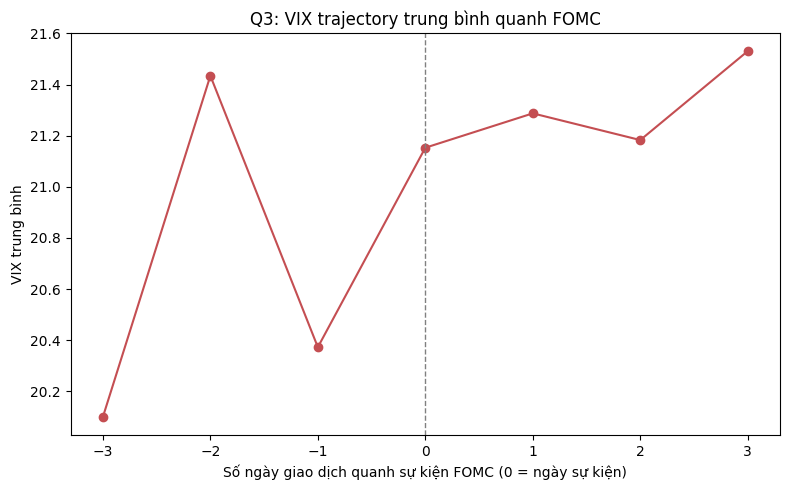

In [24]:
traj_offsets = range(-3, 4)
traj_means = []

for offset in traj_offsets:
    vals = []
    for ed in event_windows:
        idx = trading_dates.index(ed)
        d = trading_dates[idx + offset] if 0 <= idx + offset < len(trading_dates) else None
        if d is not None and d in vix_lookup:
            vals.append(vix_lookup[d])
    traj_means.append(np.mean(vals))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(traj_offsets), traj_means, marker="o", color="#C44E52")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Số ngày giao dịch quanh sự kiện FOMC (0 = ngày sự kiện)")
ax.set_ylabel("VIX trung bình")
ax.set_title("Q3: VIX trajectory trung bình quanh FOMC")
plt.tight_layout()
plt.show()

### Trả lời Q3

VIX tăng nhẹ trước và sau FOMC, nhưng cả hai thay đổi đều không có ý nghĩa thống kê. Vì vậy, chưa có bằng chứng rõ ràng về việc VIX tăng trước FOMC hoặc xảy ra “volatility crush” sau FOMC.